<a href="https://colab.research.google.com/github/Insight-Sogang-Univ/insight-15th/blob/minyoung/advanced/minyoung/session04/%EC%96%B8%EC%96%B4%EB%AA%A8%EB%8D%B8_%EC%82%AC%EC%A0%84%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 언어모델 사전과제

## 1. NLP와 언어 모델  
  
### (1) NLP (Natural Language Processing)  
  
**자연어**: 인간이 소통을 위해 자연스럽게 발생시켜 사용하는 언어 (=그냥 우리가 쓰는 말) <-> 컴퓨터가 이해하는 프로그램 언어와 대비  
  
- 프로그래밍 언어(ex. C, Pythong): 엄격한 규칙, 논리적, 일대일 대응. 에러 나면 돌아가지 않음
- 자연어: 인간이 소통을 위해 사용하는 언어. 모호함, 유연함. 일대다 대응
  
  
**NLP**: 자연어의 의미를 분석하고 컴퓨터가 처리할 수 있도록 하는 AI 기술 분야  
- 모호한 자연어를 컴퓨터가 이해할 수 있는 숫자(vector)로 변환하여 유의미한 가치 창출
- 음성 인식, 내용 요약, 번역, 감정 분석, 텍스트 분류, 챗봇 등
- 과정
  1. 데이터 수집: 웹 크롤링, API 호출, 데이터셋 다운로드 등
  2. 텍스트 전처리: 모델이 이해할 수 있는 형태로 텍스트를 정제
  3. 텍스트 표현: 텍스트를 수치로 표현하여 머신러닝/딥러닝 입력 가능하게 변환
  4. 모델 학습 및 예측: 텍스트 분류, 문장 생성 등 목적에 맞는 NLP 테스크 수행
  5. 후처리 및 응용: 출력 다듬기, 응용 시스템, 평가 지표 확인 등
    

  
**자연어 특징**  
1. 이산적 데이터
- 연속적 신호인 이미지, 소리와 다르게 언어는 단어라는 독립적인 단위로 구성
- 컴퓨터가 이해할 수 있도록 이산적인 단어를 연속적인 벡터로 변환하는 과정(Embedding) 필요
  
2. 순차적 데이터
- 단어 나열 순서에 따라 문장 의미가 결정됨
- 데이터의 앞뒤 관계와 위치 정보를 유지하며 처리할 수 있는 모델 구조가 필요 (RNN, Transformer 등)
  
3. 중의성과 모호성
- 동일한 단어라도 문맥에 따라 뜻이 달라짐
- 단어 하나가 아닌 문맥을 전체적으로 파악해야 함
  
4. 희소성
- Zipf의 법칙: 단어의 조합이 무한에 가까움, but 우리가 가진 데이터에 나타나는 조합은 극히 일부
- 한 번도 본 적 없는 문장이 들어와도 단어 간 유사도를 이용해 확률적으로 추론할 수 있어야 함
  
5. 가변성과 진화
- 언어 고정되어 있지 않음 (신조어, 오타, 이모지 등 수시로 등장하며 문법 파괴가 잦음)
- 데이터로부터 유연하게 패턴을 학습하는 머신러닝 방법 필요
  
### (2) 언어 모델  
  
- 언어 모델: 인간이 말하고 쓰는 방식을 모방하는 시스템
- 단어 시퀀스(문장)에 확률을 할당하여 가장 자연스러운 단어 시퀀스를 찾아내는 모델
  - 자연스러움을 판단하는 방법: 이전 단어들이 주어졌을 때, 다음 단어를 예측하도록 훈련
- 구분: 통계 기반 vs 인공 신경망 기반

## 2. 통계적 언어 모델 (SLM)  
  
### (1) SLM (Statistic Language Model)  
  
**분포 가설**: 비슷한 문맥에서 함께 나타나는 단어들은 비슷한 의미를 가짐  
  
- 조건부 확률: 특정 단어가 앞에 존재한다는 조건 하에 그 다음에 올 단어를 예측
- 카운트기반 확률: 이전 단어 시퀀스의 등장 빈도를 통해 다음 단어의 확률을 계산
  - 희소 문제: 이전에 경험한 적이 있는 조합에 대해서만 잘 예측할 수 있음
  
> SLM은 새로운 문장 조합에 약함! -> *새로운 문장 조합*에도 적용할 수 있는 신경망 모델 필요  
  
  
### (2) N-gram  
  
> SLM은 문장이 길어질수록 다음 단어를 계산하기 어려움 -> 전체 문장 대신 문장의 일부만 보는게 어떨까?  
  
- 예측하고자 하는 단어를 포함해 N개의 단어를 봄 (기존 단어 중 N-1개를 봐서 최종 단어를 예측)
- SLM과 동일하게 확률적 선택에 따라 더 많이 등장한 것으로 예측, but N-gram은 문장의 일부만 봄
  
**N-gram의 한계**  
1. 희소 문제
- 데이터 부족: 훈련 데이터에서 나타나지 않은 단어 조합은 확률이 0 -> 해당 단어 시퀀스를 예측하거나 평가 불가
- N의 크기 커질수록 훈련 데이터에서 해당 조합 찾기 어려움 -> 희소 문제 심해짐
  
2. 문맥 제한
- 앞선 N-1개의 단어만 고려 -> 문장 앞부분에 나온 정보를 뒷부분 결정에 반영 X
  

### (3) Perplexity (PPL)  
  
**PPL**: 언어 모델이 문장을 얼마나 혼란스러워하는지 수치로 나타냄  
- 문장 W가 희소하게 등장할수록 PPL 커짐
  - 문장 W가 희소하게 등장하면 모델이 훈련 데이터에서 더 적게 봤으므로 예측할 때 혼란스러움
- 단어 개수 N이 커질수록 PPL 낮아짐
  - 함께 보는 단어들이 많아지니까, 희소한 부분이 있더라도 그 안에 예측 쉬운 단어들도 함께 있어서 덜 혼란스러움

> 신경망 기반 언어 모델은 단어와 문맥 간 관계 학습하여 일반화하는 능력 뛰어남 -> 훈련 데이터에서 직접 보지 못한 문장 등장할 때 유연하게 대처 가능  


## 3. 신경망 언어 모델 (NLM)  
  
**임베딩**: 토큰화된 각 단위를 숫자의 벡터로 변환  
  
- 워드 임베딩: SLM은 단어를 단순히 이름으로 기억했다면, NLM은 모든 단어를 거대한 다차원 지도 위의 한 점으로 보냄
- 단어를 기호에서, 의미를 가진 숫자로 바꿈으로써, 데이터에 없는 문맥도 어느 정도 예측할 수 있는 *일반화 능력*  
  
**NNLM의 특징**  
- 미학습 단어도 유사 단어를 통해 확률 추론 가능
- 가중치만 저장하여 저장 공간 아낌
- 임베딩 벡터 간 거리를 계산하여 의미 파악 가능

## 4. 딥러닝 기반 언어 모델  
  
### (1) Transformer의 등장  
  
**RNN / LSTM 한계**  
- 병렬화 불가: 현재 입력 처리 위해서는 이전 출력 결과 필요하여 순차적 진행
- 기울기 소실, 폭주
- 장기 의존성 문제: LSTM이 어느 정도는 극복했으나, 긴 문장에서는 여전히 발생
  
> 위 문제 들은 모두 신경망의 깊이를 깊게 만드는 것을 불가능하게 함 -> Transformer로 극복  
  
**Transformer**  
  
[구조]  
  
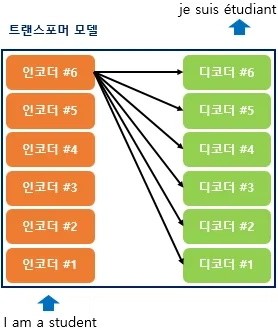  
  
- RNN 기반 모델: 인코더와 디코더가 RNN 셀 하나를 반복 사용
- Transformer: RNN 셀을 반복 사용하는 대신, 인코더와 디코더를 여러 층으로 깊게 쌓자
  
> 신경망 깊게 쌓으면서 언어 모델의 표현력이 높아져 현재의 딥러닝 기반 언어모델을 만들 수 있었음  
  
[전이학습]  
1. 사전 학습  
- 레이블이 없는 방대한 데이터를 스스로 학습하게 함
- 언어의 구조, 상식, 문맥을 통째로 이해하는 범용적 뇌를 가진 모델 탄생
  
2. 미세 조정 (Fine Tuning)
- 사전 학습된 모델 위에 우리가 해결하고 싶은 특정 작업의 데이터를 아주 조금만 더 학습 시킴
- 적은 데이터로도 특정 분야의 전문가가 된 모델 탄생
  

### (2) BERT  
  
**BERT**: Bidirectional Encoder Representations from Transformers  
- Bidirectional: 텍스트의 앞뒤 문맥을 동시에 고려 (=양방향 작동)
- Encoder: 입력값을 벡터로 바꿔주는
- Transforemrs: 딥러닝 모델
  
[특징]  
- 양방향: 문장 읽을 때 앞뒤를 동시에 고려
- 트랜스포머 기반: 트랜스포머 구조의 인코더 부분만 사용
- 사전 학습 + 파인 튜닝: 큰 데이터로 먼저 일반적인 언어 능력 배우고, 나중에 특정 과제에 맞게 살짝 조정
  - 사전 학습은 Masked Language Model과 Next Sentence Prediction을 통해 진행됨
  
[학습 방법]  
- 구조: Transformer의 encoder를 여러개 쌓아 올린 구조
  
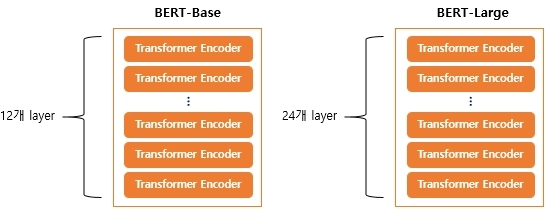  
  
- 처리 과정: input -> embedding -> 트랜스포머 인코더 12개(or 24개) -> output
  - 인코더: 입력 문장을 이해하고 요약된 의미 벡터로 변환
  - 임베딩 된 입력 문장이 여러 개의 인코더를 통과하며 각 단어의 의미를 문맥적으로 풍부하게 만듦
  - Token Embedding + Segment Embedding + Position Embedding
  - decoder 없고 encoder만 존재 -> 문장 이해를 목적으로 함
  
- 사전 학습
  1. Masked Language Model (MLM)
  - 빈칸 채우기 방식: 무작위로 문장 내 빈칸을 뚫고, 그 빈칸에 들어갈 단어를 예측하는 방식으로 학습
  2. Next Sentence Prediction (NSP)
  - 두 문장에 대해, 문장들의 관계를 학습
  - 두 문장이 이어지는 논리 흐름 학습

[BERT 이후의 모델]  
  
1. RoBERTa: BERT의 사전 훈련 프로세스를 개선하여 성능을 향상시킨 실전형 모델
- 더 거대한 데이터셋, 더 긴 시간 학습
- NSP 제거 (성능 이슈)
- 배치 크기 및 학습률 최적화
- 마스킹 패턴을 동적으로 변경해 다양한 패턴 학습
  
2. ALBERT (A Lite BERT): BERT 경량화 버전, 가볍지만 성능 유지
- 레이어 간 파라미터를 공유해 모델 크기 감소
- 임베딩 행렬을 두 개의 더 작은 행렬로 분해하여 계산 비용과 메모리 요구량 감소
  

### (3) GPT  
  
**GPT**: deocder 기반, 지금까지의 단어를 바탕으로 다음 단어를 예측  
  
- few-shot learning: 몇 개의 예시를 보고 task를 수행하느냐에 따라 이름 붙음
  - zero-shot: 예시 없이 문제 지시만 주고 task 수행
  - one-shot: 1개의 예시만 보고 task 수행
  - few-shot: 몇 개의 예시를 보고 task 수행
- 단방향: 앞 단어만 참고하여 다음 단어를 예측
- 문장의 생성을 목적으로 함
  

### (4) LLM  
  
**LLM**: Large Language Model, 방대한 양의 데이터를 학습하여 자연어 및 기타 유형의 콘텐츠를 이해하고 생성
  
[작동 방식]  
1. 대규모 학습  
- 인터넷의 웹페이지, 책, 기사 등 방대한 데이터를 학습
- 단순히 정보를 암기하는 것을 넘어, 단어와 단어 사이의 관계, 문맥적 의미, 문법 구조, 언어의 패턴을 스스로 터득
  
2. 예측 및 생성
- 사용자의 프롬프트를 받으면, 학습한 패턴을 기반으로 다음에 올 가장 확률 높은 단어를 순서대로 예측하며 응답 생성
  
> GPT 방식 사용 (decoder 기반): 단순히 이해에서 그치는 게 아니라 텍스트를 생성하는 것을 궁극적인 목표로 하기 때문  
  
[LLM 한계]  
- Hallucination: 그럴듯하지만 틀린 정보 말하는 것
- 업데이터 비용: 파라미터 수 너무 많아서 새로운 정보 반영할 때 계산량이 너무 많음
  

### (5) RAG  
  
**RAG**: Retrieval Augmented Generation, 질문에 대해 모델이 모르면 검색해서 답하는 구조  
  
[RAG 구조]  
  
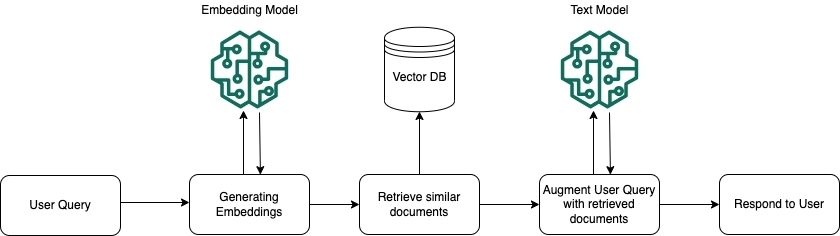  
  
- 질의 인코더: 사용자 질문을 벡터로 변환
- 지식 검색기: 인코딩된 질문을 바탕으로 외부 지식에서 관련 내용 검색
- 지식 증강 생성기: 검색한 내용을 참고하여 답변 생성
  
[장점]  
- 최신 정보 반영 가능
- hallucination 문제 감소
- 정보 정확성 증가
  
[CAG]  
- Credibility-Aware Generation
- 검색된 문서 중 일부가 신뢰성이 낮을 경우 답변의 정확도가 떨어지는 기존 RAG의 한계를 보완하는 프레임워크
- 잘못된 컨텍스트가 모델 성능에 미치는 부정적 영향 최소화
- 모델이 문서를 단순히 활용하는 수준을 넘어 문서의 신뢰도를 스스로 판단하고 활용할 수 있도록 훈련시키는 기법
- 구조
  - 질문 입력 -> 정보 검색 -> 각 정보의 신뢰도 평가 -> 높은 신뢰도 정보 우선 사용 -> 최종 답변 생성

  
### (6) LangChain  
  
> LLM+RAG 직접 구현하는 것 복잡하므로 이러한 모델 파이프라인을 쉽게 구성할 수 있도록 도와줌  
  
[LangChain]  
- LLM 기반으로 앱 제작시 필요한 구성 요소를 쉽게 연결
- 파이썬, JavaScript 라이브러리 제공 -> 다양하게 활용 가능
- 추상화: LLM 서비스 만들 때 필요한 각종 작업을 간결하게 표현 (간소화)
- 체이닝: 자주 활용하는 주요 컴포넌트를 쉽게 연결해서 LLM 서비스의 로직을 쉽게 파악 (Input -> 컴포넌트 -> Output)
  
[LangGraph]  
- LangChain 한계: 선형적인 체인 구조를 주로 사용하므로, 중간에 조건에 따라 다른 작업을 수행하거나, 결과가 마음에 들지 않을 때 이전 단계로 돌아가서 다시 시행하는 복잡한 로직 구현하기 어려움
- 비선형적이고 동적인 프로세스
  - 사이클, 루프 만들 수 있음 (검색과 검증을 반복하며 완벽한 답을 찾아냄)
- 노드: 특정 작업을 수행하는 단위, 랭체인의 컴포넌트를 그대로 가져와 노드로 활용할 수 있음
- 엣지: 노드와 노드를 연결하는 선, 어떤 노드에서 다음 노드로 이동할지 결정
  - 조건부 엣지를 통해 분기 로직(if-else)을 쉽게 구현

[LangSmith]  
- LLM 기반 애플리케이션을 위한 통합 개발 및 운영 플랫폼
- 기능
  - 디버깅 및 추적: LLM 애플리케이션의 모든 실행 과정을 단계별로 시각화
  - 테스트 및 평가: 미리 준비된 질문과 정답 데이터셋을 만들어, 개발 중인 LLM 애플리케이션의 성능을 자동으로 평가
  - 모니터링: 실제 사용자들이 애플리케이션 어떻게 사용하는지 모니터링
  - 프롬프트 허브: 다양한 프롬프트 저장, 버전 관리, 쉽게 테스트할 수 있는 공간 제공

[외부 API 활용]  
- 내부 지식만을 이용해서 해결할 수 없는 질문에 대해서는 외부 API와 연동해서 답변 가능


## 5. sLM (small Language Model)  
  
**sLM**: 소규모 언어 모델, 자연어 콘텐츠를 처리, 이해, 생성할 수 있는 AI 모델  
- LLM보다 적은 매개변수를 가짐
- 더 작고, 효율적이어서 메모리와 연산 자원 적게 사용
- 모바일 앱처럼 리소스 제한된 환경, 오프라인 추론 해야 하는 상황에 적합
- ex. DistilBERT, Gemma, GPT-4o mini, Llama, Ministral, Phi 등
  

[모델 압축]  
1. 가지치기: 신경망에서 중요도가 더 낮거나 중복되거나 불필요한 매개변수 제거  
- 일반적으로 가지치기되는 매개변수: 뉴런 간 연결에 해당되는 숫자 가중치, 뉴런 자체, 신경망 계층 등
  
2. 양자화: 고정밀 데이터를 저정밀 데이터로 변환
- 계산 부하 감소, 추론 속도 상승
  
3. 저차원 분해: 큰 가중치 행렬을 더 작은 저차원 행렬로 분해
- 더 간결한 근사치를 사용하면 매개변수 수와 계산 횟수 감소 -> 복잡한 행렬 연산 단순화
  
4. 지식 증류: 사전 학습된 교사 모델의 학습 내용을 학생 모델로 이전
- 학생 모델은 교사 모델의 예측과 일치시키고 기본 추론 과정을 모방하도록 학습
- 더 큰 모델의 지식이 더 작은 모델로 기본적으로 증류됨
  
[장점]  
- 성능
  - 효과적인 성능: 작은 모델을 해당 업무에 맞게 fine-tuning하면 필요한 기능만 빠르고 안정적으로 수행 가능
  - 지연 시간 감소: 모델 크기 작아서 계산량 감소
  - 보안: 작은 모델이라서 기업 내부 서버나 개인 기기에서 직접 실행 가능하므로 민감한 데이터를 외부 클라우드 API로 보내지 않아도 됨
- 비용
  - 접근성: 고성능 GPU 서버 없이 사용 가능
  - 효율성: 저장 공간, 메모리, 연산 자원 적게 사용
  - 에너지 효율: 계산량 감소하여 전력 소비 감소
  - 비용 절감: 추론 비용, 서버 비용, GPU 비용, API 호출 비용 감소

[한계]  
- 편향: 더 큰 모델에 존재하는 편향까지 함께 전달되면 성능 저하됨
- 제한된 일반화, 복잡한 작업에서의 성능 저하: 특정 작업에 대해 미세 조정하므로 포괄적 지식이 필요한 작업에 취약
- 환각: 정보 적고 추론 능력 낮으므로 발생 가능
  
[결합 추론]  
> LLM과 sLM 결합  
- 복잡하고 어려운 작업에서는 LLM, 가볍고 간단한 작업에서는 sLM을 적절히 배분하여 사용
- LLM 수준의 높은 정확도 달성하면서도 LLM 토큰 사용량을 최대 90%까지 절약 가능